In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score,precision_score, recall_score,f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf


import kagglehub
import os


In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

file_path = os.path.join(path, "creditcard.csv")

df = pd.read_csv(file_path)

Path to dataset files: C:\Users\mar_c\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


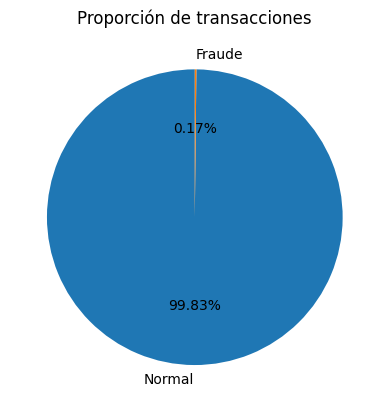

In [4]:
counts = df['Class'].value_counts()

plt.figure()
plt.pie(
    counts.values,
    labels=['Normal', 'Fraude'],
    autopct='%1.2f%%',
    startangle=90
)

plt.title("Proporción de transacciones")
plt.show()

## EDA

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


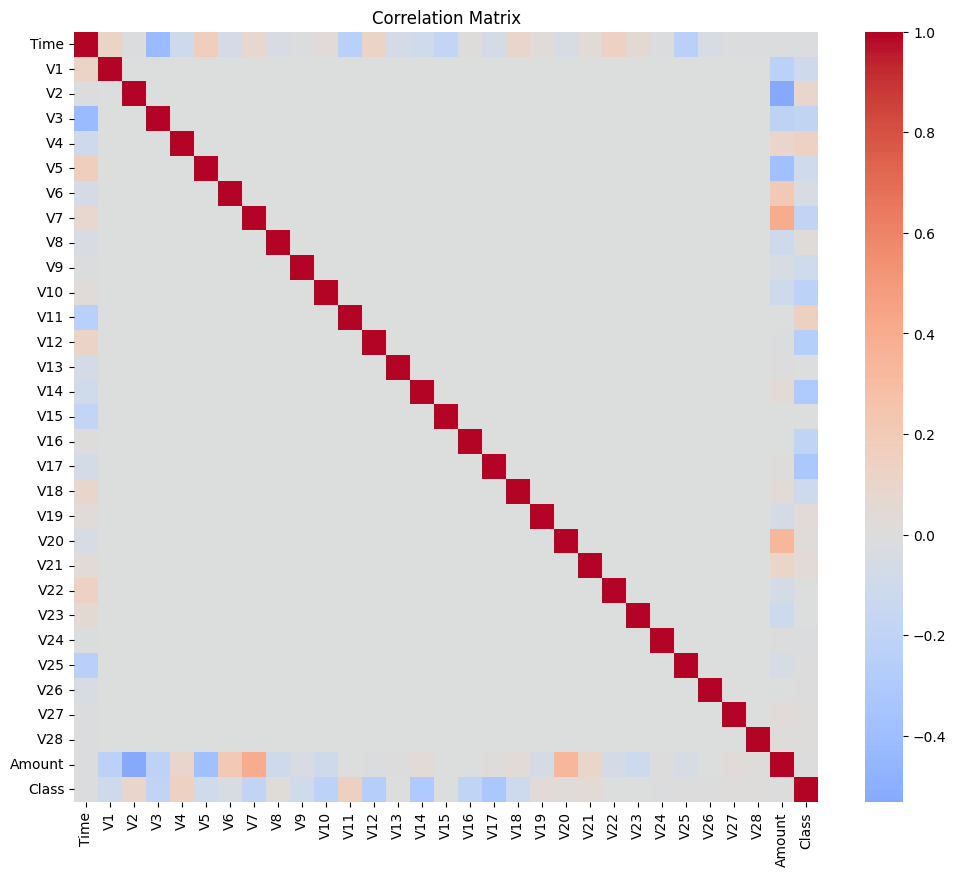

In [6]:
corr = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Correlation Matrix")
plt.show()

In [7]:
corr_target = df.corr()['Class'].sort_values(ascending=False)
corr_target

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

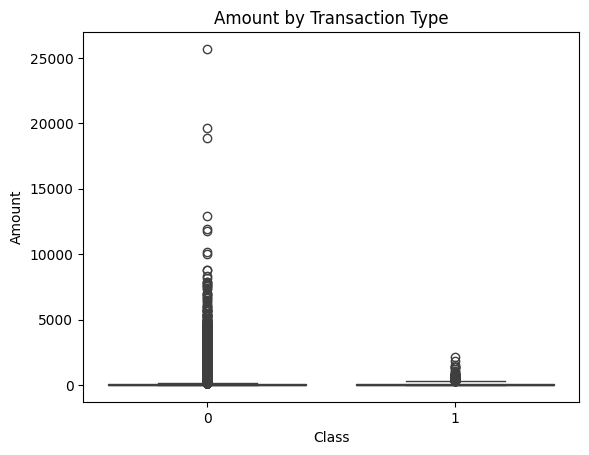

In [8]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount by Transaction Type")
plt.show()

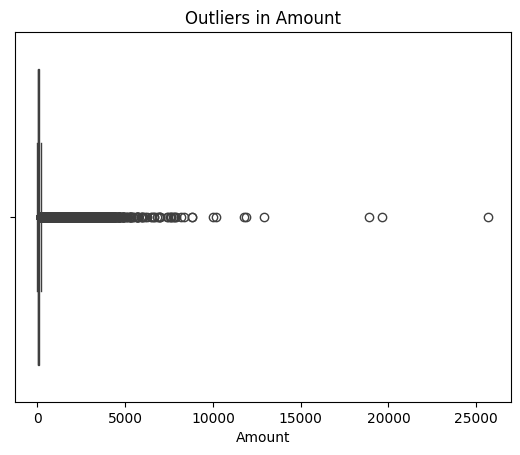

In [9]:
## Inspect outliers in Amount

sns.boxplot(x=df['Amount'])
plt.title("Outliers in Amount")
plt.show()

In [10]:
## Missing values

df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

<Axes: xlabel='Amount', ylabel='Count'>

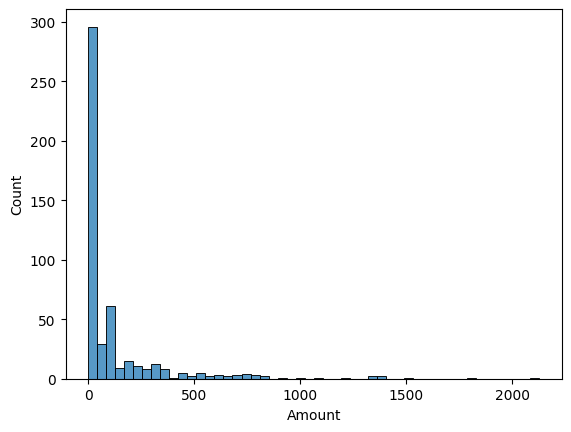

In [11]:
## Amount distribution for fraudulent transactions
sns.histplot(data=df[df.Class==1], x="Amount", bins=50)

# Train/Test Split and Normalization

In [12]:

# Separate features (X) and target (y)
X = df.drop('Class', axis=1)  # all variables except the label
y = df['Class']               # target variable (fraud or not)


# Split into train and test

# stratify=y ensures the class imbalance (fraud vs normal)
# remains the same in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Define which columns will be scaled

# We only scale Amount and Time because:
# - V1–V28 are already transformed (PCA)
columns_to_scale = ['Amount', 'Time']


# Create transformer
# ColumnTransformer allows applying transformations
# only to certain columns while leaving the rest unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), columns_to_scale)  # scales only these columns
    ],
    remainder='passthrough'  # leaves the rest unchanged (V1–V28)
)

# Fit the scaler ONLY on the training set

# fit_transform learns the mean and std from the training set
# and transforms the data (prevents data leakage)
X_train_prepared = preprocessor.fit_transform(X_train)

# Transform test WITHOUT refitting
# only applies the same transformation learned from the training set
X_test_prepared = preprocessor.transform(X_test)

# Red neuronal

In [13]:

# Compute class weights
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

# Define neural network
input_dim = X_train_prepared.shape[1]

model = Sequential([
    Input(shape=(X_train_prepared.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['Precision', 'Recall']
)

# Train model
history = model.fit(
    X_train_prepared,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

# Class weights: {np.int64(0): np.float64(0.5008661206149896), np.int64(1): np.float64(289.14340101522845)}
# Indica que que la clase normal (0) tiene menos peso que la clase 1 osea el fraude por lo que penaliza mas errores en fraudes

Class weights: {np.int64(0): np.float64(0.5008661206149896), np.int64(1): np.float64(289.14340101522845)}
Epoch 1/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - Precision: 0.0195 - Recall: 0.8939 - loss: 0.2442 - val_Precision: 0.0931 - val_Recall: 0.9157 - val_loss: 0.1271
Epoch 2/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Precision: 0.0658 - Recall: 0.9132 - loss: 0.1515 - val_Precision: 0.0684 - val_Recall: 0.9157 - val_loss: 0.1116
Epoch 3/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - Precision: 0.0671 - Recall: 0.9293 - loss: 0.1269 - val_Precision: 0.0513 - val_Recall: 0.9277 - val_loss: 0.1151
Epoch 4/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Precision: 0.0678 - Recall: 0.9325 - loss: 0.1123 - val_Precision: 0.0485 - val_Recall: 0.9518 - val_loss: 0.1234
Epoch 5/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - Precision: 0.0677 - Recall: 0.9421 - loss: 0.1015 - val_Precision: 0.0715 - val_Recall: 0.9277 - val_loss: 0.0827
Epoch 6/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - 

In [14]:
# 1. Obtener probabilidades en test
y_proba_test = model.predict(X_test_prepared).ravel()

# 2. Aplicar threshold inicial
threshold = 0.5
y_pred_test = (y_proba_test >= threshold).astype(int)

# 3. Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

# 4. Métricas principales
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

roc_auc = roc_auc_score(y_test, y_proba_test)
pr_auc = average_precision_score(y_test, y_proba_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, digits=4))

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("FPR:", round(fpr, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

# 5. Mostrar componentes de la matriz por separado
print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step
Confusion Matrix:
[[56072   792]
 [   10    88]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9861    0.9929     56864
           1     0.1000    0.8980    0.1800        98

    accuracy                         0.9859     56962
   macro avg     0.5499    0.9420    0.5864     56962
weighted avg     0.9983    0.9859    0.9915     56962

Precision: 0.1
Recall: 0.898
FPR: 0.0139
ROC-AUC: 0.9785
PR-AUC: 0.685

TN: 56072
FP: 792
FN: 10
TP: 88


In [15]:
# 1. Obtener probabilidades en test
y_proba_test = model.predict(X_test_prepared).ravel()

# 2. Probar varios thresholds
thresholds = np.arange(0.2, 0.98, 0.02)

resultados = []

for threshold in thresholds:
    # Convert probabilities to classes
    y_pred_test = (y_proba_test >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

    # Metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Save results
    resultados.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "fpr": fpr,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

# 3. Convertir a DataFrame
df_thresholds = pd.DataFrame(resultados)

# Orden opcional: por recall descendente y luego precision descendente
df_thresholds = df_thresholds.sort_values(
    by=["recall", "precision"],
    ascending=[False, False]
).reset_index(drop=True)


best = df_thresholds.sort_values("f1_score", ascending=False).iloc[0]

print(best)

threshold_optimo = best["threshold"]


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 870us/step
threshold        0.960000
precision        0.588652
recall           0.846939
f1_score         0.694561
fpr              0.001020
tn           56806.000000
fp              58.000000
fn              15.000000
tp              83.000000
Name: 38, dtype: float64


In [16]:

# 1. Definir class weights manuales
class_weights = {0: 1.0, 1: 75.0}

# 2. Definir modelo
model = Sequential([
    Input(shape=(X_train_prepared.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# 3. Compilar modelo
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['Precision', 'Recall']
)

# 4. Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 5. Entrenamiento
history = model.fit(
    X_train_prepared,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# 6. Evaluación en test con threshold fijo
y_proba_test = model.predict(X_test_prepared).ravel()

threshold = threshold_optimo
y_pred_test = (y_proba_test >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

roc_auc = roc_auc_score(y_test, y_proba_test)
pr_auc = average_precision_score(y_test, y_proba_test)

print("Threshold:", threshold)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, digits=4))

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1_score, 4))
print("FPR:", round(fpr, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

Epoch 1/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - Precision: 0.1256 - Recall: 0.7621 - loss: 0.1765 - val_Precision: 0.3483 - val_Recall: 0.8434 - val_loss: 0.0180
Epoch 2/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Precision: 0.2491 - Recall: 0.8489 - loss: 0.0959 - val_Precision: 0.1978 - val_Recall: 0.8675 - val_loss: 0.0328
Epoch 3/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - Precision: 0.2473 - Recall: 0.8746 - loss: 0.0812 - val_Precision: 0.4730 - val_Recall: 0.8434 - val_loss: 0.0148
Epoch 4/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Precision: 0.3297 - Recall: 0.8714 - loss: 0.0814 - val_Precision: 0.3288 - val_Recall: 0.8675 - val_loss: 0.0210
Epoch 5/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - Precision: 0.3261 - Recall: 0.8714 - loss: 0.0638 - val_Precision: 0.4260 - val_Recall: 0.8675 - val_loss: 0.0149
Epoch 6/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - Precision: 0.3265 - Recall: 0.8714 - loss: 0.0643 - val_Precision: 0.4863 - val_Recall: 0.8554 - val_loss:

In [17]:
# 1. Lista de pesos a probar para la clase fraude (clase 1)
weights_to_try = [80,90, 100,150,200]
# Threshold fijo
threshold = threshold_optimo

# Guardar resultados
results = []

# 2. Ciclo para probar diferentes class_weights
for fraud_weight in weights_to_try:
    print(f"\nProbando class_weight = {{0: 1.0, 1: {fraud_weight}}}")

    class_weights = {0: 1.0, 1: fraud_weight}

    # Fijar semilla para más consistencia entre pruebas
    tf.keras.utils.set_random_seed(42)

    # Definir modelo
    model = Sequential([
        Input(shape=(X_train_prepared.shape[1],)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    # Compilar modelo
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['Precision', 'Recall']
    )

    # EarlyStopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # Entrenamiento
    history = model.fit(
        X_train_prepared,
        y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=256,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0
    )

    # Probabilidades y predicciones
    y_proba_test = model.predict(X_test_prepared, verbose=0).ravel()
    y_pred_test = (y_proba_test >= threshold).astype(int)

    # Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

    # Métricas
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc = roc_auc_score(y_test, y_proba_test)
    pr_auc = average_precision_score(y_test, y_proba_test)

    # Guardar resultados
    results.append({
        "fraud_weight": fraud_weight,
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "fpr": fpr,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

# 3. Resultados en DataFrame
df_results = pd.DataFrame(results)

# Orden sugerido: mejor precision con recall alto
df_results = df_results.sort_values(
    by=["precision", "recall"],
    ascending=[False, False]
).reset_index(drop=True)

print(df_results)


Probando class_weight = {0: 1.0, 1: 80}

Probando class_weight = {0: 1.0, 1: 90}

Probando class_weight = {0: 1.0, 1: 100}

Probando class_weight = {0: 1.0, 1: 150}

Probando class_weight = {0: 1.0, 1: 200}
   fraud_weight  threshold  precision    recall  f1_score       fpr   roc_auc  \
0            80       0.96   0.752381  0.806122  0.778325  0.000457  0.980661   
1            90       0.96   0.725664  0.836735  0.777251  0.000545  0.976929   
2           100       0.96   0.709402  0.846939  0.772093  0.000598  0.977393   
3           150       0.96   0.661290  0.836735  0.738739  0.000739  0.980862   
4           200       0.96   0.643411  0.846939  0.731278  0.000809  0.982740   

     pr_auc     tn  fp  fn  tp  
0  0.742041  56838  26  19  79  
1  0.736952  56833  31  16  82  
2  0.747237  56830  34  15  83  
3  0.734893  56822  42  16  82  
4  0.723088  56818  46  15  83  


In [ ]:
# 1. Configuración fija
threshold = 0.90 
class_weights = {0: 1.0, 1: 90}

learning_rate = 0.001
batch_size = 256
epochs = 30

# 2. Arquitecturas a probar
# Cada tupla representa neuronas por capa oculta
architectures = [
    (16,),
    (32,),
    (64,),
    (32, 16),
    (64, 32),
    (128, 64),
    (64, 32, 16)
]

# 3. Función para construir modelo
def build_model(architecture, input_dim):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in architecture:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(0.2))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['Precision', 'Recall']
    )
    return model

# 4. Probar arquitecturas
results = []

for architecture in architectures:
    print(f"\nProbando arquitectura: {architecture}")

    tf.keras.utils.set_random_seed(42)

    model = build_model(architecture, X_train_prepared.shape[1])

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_prepared,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0
    )

    # Probabilidades y predicciones
    y_proba_test = model.predict(X_test_prepared, verbose=0).ravel()
    y_pred_test = (y_proba_test >= threshold).astype(int)

    # Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

    # Métricas
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc = roc_auc_score(y_test, y_proba_test)
    pr_auc = average_precision_score(y_test, y_proba_test)

    results.append({
        "architecture": str(architecture),
        "threshold": threshold,
        "class_weight_1": class_weights[1],
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "fpr": fpr,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

# 5. Resultados
df_architectures = pd.DataFrame(results)

df_architectures = df_architectures.sort_values(
    by=["precision", "recall"],
    ascending=[False, False]
).reset_index(drop=True)

print(df_architectures)


Probando arquitectura: (16,)

Probando arquitectura: (32,)

Probando arquitectura: (64,)

Probando arquitectura: (32, 16)

Probando arquitectura: (64, 32)

Probando arquitectura: (128, 64)

Probando arquitectura: (64, 32, 16)
   architecture  threshold  class_weight_1  learning_rate  batch_size  \
0  (64, 32, 16)        0.9              90          0.001         256   
1         (16,)        0.9              90          0.001         256   
2      (32, 16)        0.9              90          0.001         256   
3         (32,)        0.9              90          0.001         256   
4     (128, 64)        0.9              90          0.001         256   
5      (64, 32)        0.9              90          0.001         256   
6         (64,)        0.9              90          0.001         256   

   precision    recall  f1_score       fpr   roc_auc    pr_auc     tn  fp  fn  \
0   0.719298  0.836735  0.773585  0.000563  0.981324  0.701796  56832  32  16   
1   0.703390  0.846939  0.

In [20]:


# 1. Fijar semilla
tf.keras.utils.set_random_seed(42)

# 2. Configuración fija
class_weights = {0: 1.0, 1: 90}
learning_rate = 0.001
batch_size = 256
epochs = 30

# 3. Definir modelo con arquitectura (32,)
model = Sequential([
    Input(shape=(X_train_prepared.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# 4. Compilar modelo
model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='binary_crossentropy',
    metrics=['Precision', 'Recall']
)

# 5. EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 6. Entrenar modelo
history = model.fit(
    X_train_prepared,
    y_train,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=0
)

# 7. Obtener probabilidades en test
y_proba_test = model.predict(X_test_prepared, verbose=0).ravel()

# 8. Probar varios thresholds
thresholds = np.arange(0.70, 0.99, 0.02)

results = []

for threshold in thresholds:
    y_pred_test = (y_proba_test >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc = roc_auc_score(y_test, y_proba_test)
    pr_auc = average_precision_score(y_test, y_proba_test)

    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "fpr": fpr,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

# --------------------------------------------------------
# 9. Resultados
# --------------------------------------------------------
df_thresholds_32 = pd.DataFrame(results)

df_thresholds_32 = df_thresholds_32.sort_values(
    by=["recall", "precision"],
    ascending=[False, False]
).reset_index(drop=True)

print(df_thresholds_32)

    threshold  precision    recall  f1_score       fpr   roc_auc    pr_auc  \
0        0.92   0.699187  0.877551  0.778281  0.000651  0.977435  0.738837   
1        0.90   0.666667  0.877551  0.757709  0.000756  0.977435  0.738837   
2        0.88   0.646617  0.877551  0.744589  0.000827  0.977435  0.738837   
3        0.86   0.641791  0.877551  0.741379  0.000844  0.977435  0.738837   
4        0.84   0.618705  0.877551  0.725738  0.000932  0.977435  0.738837   
5        0.82   0.589041  0.877551  0.704918  0.001055  0.977435  0.738837   
6        0.80   0.562092  0.877551  0.685259  0.001178  0.977435  0.738837   
7        0.78   0.534161  0.877551  0.664093  0.001319  0.977435  0.738837   
8        0.76   0.511905  0.877551  0.646617  0.001442  0.977435  0.738837   
9        0.74   0.485876  0.877551  0.625455  0.001600  0.977435  0.738837   
10       0.72   0.452632  0.877551  0.597222  0.001829  0.977435  0.738837   
11       0.70   0.430000  0.877551  0.577181  0.002005  0.977435

In [ ]:

# 1. Configuración fija
threshold = 0.92
class_weights = {0: 1.0, 1: 90}
batch_size = 256
epochs = 30

learning_rates = [0.001]

results = []

# 2. Loop de learning rate
for lr in learning_rates:
    print(f"\nProbando learning_rate = {lr}")

    tf.keras.utils.set_random_seed(42)

    model = Sequential([
        Input(shape=(X_train_prepared.shape[1],)),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['Precision', 'Recall']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    model.fit(
        X_train_prepared,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluación
    y_proba_test = model.predict(X_test_prepared, verbose=0).ravel()
    y_pred_test = (y_proba_test >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc = roc_auc_score(y_test, y_proba_test)
    pr_auc = average_precision_score(y_test, y_proba_test)

    results.append({
        "learning_rate": lr,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "fpr": fpr,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

# 3. Resultados
df_lr = pd.DataFrame(results)

df_lr = df_lr.sort_values(
    by=["recall", "precision"],
    ascending=[False, False]
).reset_index(drop=True)

print(df_lr)


Probando learning_rate = 0.001

Probando learning_rate = 0.01

Probando learning_rate = 0.1
   learning_rate  precision    recall  f1_score       fpr   roc_auc    pr_auc  \
0          0.001   0.699187  0.877551  0.778281  0.000651  0.977435  0.738837   
1          0.010   0.653846  0.867347  0.745614  0.000791  0.980184  0.699210   
2          0.100   0.580420  0.846939  0.688797  0.001055  0.976933  0.672776   

      tn  fp  fn  tp  
0  56827  37  12  86  
1  56819  45  13  85  
2  56804  60  15  83  


In [23]:

# 1. Configuración fija
threshold = 0.92
class_weights = {0: 1.0, 1: 90}
learning_rate = 0.001
epochs = 30

batch_sizes = [64, 128, 256, 512]

results = []

# 2. Loop de batch size
for batch_size in batch_sizes:
    print(f"\nProbando batch_size = {batch_size}")

    tf.keras.utils.set_random_seed(42)

    model = Sequential([
        Input(shape=(X_train_prepared.shape[1],)),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['Precision', 'Recall']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_prepared,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0
    )

    # 3. Evaluación en test
    y_proba_test = model.predict(X_test_prepared, verbose=0).ravel()
    y_pred_test = (y_proba_test >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc = roc_auc_score(y_test, y_proba_test)
    pr_auc = average_precision_score(y_test, y_proba_test)

    results.append({
        "batch_size": batch_size,
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "fpr": fpr,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

# 4. Resultados
df_batch = pd.DataFrame(results)

df_batch = df_batch.sort_values(
    by=["recall", "precision"],
    ascending=[False, False]
).reset_index(drop=True)

print(df_batch)


Probando batch_size = 64

Probando batch_size = 128

Probando batch_size = 256

Probando batch_size = 512
   batch_size  threshold  precision    recall  f1_score       fpr   roc_auc  \
0         256       0.92   0.699187  0.877551  0.778281  0.000651  0.977435   
1          64       0.92   0.623188  0.877551  0.728814  0.000914  0.980175   
2         128       0.92   0.688525  0.857143  0.763636  0.000668  0.980728   
3         512       0.92   0.683333  0.836735  0.752294  0.000668  0.979609   

     pr_auc     tn  fp  fn  tp  
0  0.738837  56827  37  12  86  
1  0.721678  56812  52  12  86  
2  0.705495  56826  38  14  84  
3  0.721393  56826  38  16  82  


In [25]:


# 1. Definir modelo final
model_final = Sequential([
    Input(shape=(X_train_prepared.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# 2. Compilar
model_final.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['Precision', 'Recall']
)

# 3. Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 4. Entrenar con TODO el train
model_final.fit(
    X_train_prepared,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    class_weight={0: 1.0, 1: 90},
    callbacks=[early_stop],
    verbose=1
)

# 5. Probabilidades en test
y_proba_test = model_final.predict(X_test_prepared).ravel()

# 6. Aplicar threshold final
threshold_final = 0.92
y_pred_test = (y_proba_test >= threshold_final).astype(int)

# 7. Evaluación final
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp)
recall = tp / (tp + fn)
fpr = fp / (fp + tn)

roc_auc = roc_auc_score(y_test, y_proba_test)
pr_auc = average_precision_score(y_test, y_proba_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, digits=4))

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("FPR:", round(fpr, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

Epoch 1/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - Precision: 0.0403 - Recall: 0.7749 - loss: 0.2405 - val_Precision: 0.3043 - val_Recall: 0.8434 - val_loss: 0.0462
Epoch 2/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 900us/step - Precision: 0.2822 - Recall: 0.8457 - loss: 0.1085 - val_Precision: 0.2296 - val_Recall: 0.8795 - val_loss: 0.0349
Epoch 3/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 915us/step - Precision: 0.2946 - Recall: 0.8714 - loss: 0.0886 - val_Precision: 0.2599 - val_Recall: 0.8675 - val_loss: 0.0282
Epoch 4/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Precision: 0.3014 - Recall: 0.8810 - loss: 0.0796 - val_Precision: 0.3067 - val_Recall: 0.8795 - val_loss: 0.0253
Epoch 5/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Precision: 0.3258 - Recall: 0.8810 - loss: 0.0742 - val_Precision: 0.2791 - val_Recall: 0.8675 - val_loss: 0.0251
Epoch 6/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - Precision: 0.3146 - Recall: 0.8842 - loss: 0.0776 - val_Precision: 0.2927 - val_Recall: 0.8675 - val_l